# ⚡ XGBoost Regression — From Scratch

> **Pure NumPy · No scikit-learn · No xgboost library**

This notebook implements the core XGBoost algorithm for regression **completely from scratch** using only NumPy, following the original paper:
> *Chen, T. & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. KDD'16.*

---

## 📖 Algorithm Overview

XGBoost is an **ensemble of gradient-boosted decision trees**. At each step it fits a new tree to the **negative gradient** (residuals for MSE) of the loss, then adds it with a shrinkage factor (`learning_rate`).

### Loss Function (MSE)
$$\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

### Second-Order Taylor Approximation
$$\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 \right] + \Omega(f_t)$$

Where:
- $g_i = \partial_{\hat{y}} \mathcal{L} = \hat{y}_i - y_i$ (gradient / residual for MSE)
- $h_i = \partial^2_{\hat{y}} \mathcal{L} = 1$ (hessian for MSE)
- $\Omega(f_t) = \gamma T + \frac{\lambda}{2}\sum_j w_j^2 + \alpha \sum_j |w_j|$ (regularisation)

### Optimal Leaf Weight
$$w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$$

With L1 (alpha), soft-thresholding is applied:
$$w_j^* = -\frac{\text{sign}(G_j)\cdot\max(|G_j| - \alpha, 0)}{H_j + \lambda}$$

### Split Gain
$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{G^2}{H+\lambda}\right] - \gamma$$

### Boosting Update
$$\hat{y}^{(t)} = \hat{y}^{(t-1)} + \eta \cdot f_t(x)$$

## 1. Imports

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

# Pretty print settings
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.facecolor'] = '#0d0f1a'
plt.rcParams['axes.facecolor']   = '#13162b'
plt.rcParams['axes.edgecolor']   = '#252a4a'
plt.rcParams['axes.labelcolor']  = '#e2e8f0'
plt.rcParams['xtick.color']      = '#7c85b0'
plt.rcParams['ytick.color']      = '#7c85b0'
plt.rcParams['text.color']       = '#e2e8f0'
plt.rcParams['grid.color']       = '#1a1e35'
plt.rcParams['grid.alpha']       = 0.8
plt.rcParams['font.family']      = 'DejaVu Sans'

ORANGE  = '#f97316'
AMBER   = '#fbbf24'
PURPLE  = '#6c63ff'
VIOLET  = '#a78bfa'
GREEN   = '#34d399'
PINK    = '#f472b6'

print('✅ Imports complete')

✅ Imports complete


## 2. Helper Utilities

In [20]:
def make_regression(n_samples=300, n_features=10, noise=25.0, random_state=42):
    """Generate a synthetic regression dataset."""
    rng = np.random.RandomState(random_state)
    X = rng.randn(n_samples, n_features)
    true_weights = rng.randn(n_features) * 3
    y = X @ true_weights + noise * rng.randn(n_samples)
    return X, y


def train_test_split(X, y, test_size=0.2, random_state=42):
    """Split arrays into random train and test subsets."""
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    n_test = max(1, int(np.ceil(test_size * n)))
    idx = rng.permutation(n)
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def mean_squared_error(y_true, y_pred):
    return float(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))


def mean_absolute_error(y_true, y_pred):
    return float(np.mean(np.abs(np.array(y_true) - np.array(y_pred))))


def r2_score(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1.0 - ss_res / ss_tot) if ss_tot != 0 else 0.0


print('✅ Utilities defined')

✅ Utilities defined


## 3. XGBoost Tree Node

In [21]:
class _XGBNode:
    """
    A single node in an XGBoost regression tree.

    Leaf weight formula:
        w* = -G / (H + lambda)

    With L1 (alpha):
        w* = -sign(G) * max(|G| - alpha, 0) / (H + lambda)
    """
    __slots__ = ('is_leaf', 'weight', 'feature', 'threshold', 'left', 'right')

    def __init__(self):
        self.is_leaf   = True
        self.weight    = 0.0
        self.feature   = None
        self.threshold = None
        self.left      = None
        self.right     = None


print('✅ _XGBNode defined')

✅ _XGBNode defined


## 4. XGBoost Single Tree (CART)

In [22]:
class _XGBTree:
    """
    A single regression CART tree used inside XGBoost.

    Each leaf stores the optimal weight:
        w* = -G / (H + lambda)  (with optional L1 soft-thresholding)

    Split Gain:
        Gain = 0.5 * [G_L²/(H_L+λ) + G_R²/(H_R+λ) - G²/(H+λ)] - γ
    """

    def __init__(self, max_depth=6, min_child_weight=1.0,
                 reg_lambda=1.0, reg_alpha=0.0, gamma=0.0):
        self.max_depth        = max_depth
        self.min_child_weight = min_child_weight
        self.reg_lambda       = reg_lambda
        self.reg_alpha        = reg_alpha
        self.gamma            = gamma
        self.root             = None

    # ─── Leaf weight ─────────────────────────────────────────────────────────
    def _leaf_weight(self, g, h):
        G, H = g.sum(), h.sum()
        if self.reg_alpha > 0:
            sign_G = np.sign(G)
            G = sign_G * max(abs(G) - self.reg_alpha, 0.0)
        return -G / (H + self.reg_lambda)

    # ─── Score for a leaf region ──────────────────────────────────────────────
    def _score(self, g, h):
        G, H = g.sum(), h.sum()
        if self.reg_alpha > 0:
            G = np.sign(G) * max(abs(G) - self.reg_alpha, 0.0)
        return (G ** 2) / (H + self.reg_lambda)

    # ─── Best split ───────────────────────────────────────────────────────────
    def _best_split(self, X, g, h, features):
        best_gain  = -np.inf
        best_feat  = None
        best_thr   = None
        score_node = self._score(g, h)

        for feat in features:
            x_col = X[:, feat]
            thresholds = np.unique(x_col)
            if len(thresholds) < 2:
                continue
            thresholds = (thresholds[:-1] + thresholds[1:]) / 2.0

            for thr in thresholds:
                left_mask  = x_col <= thr
                right_mask = ~left_mask

                if (h[left_mask].sum()  < self.min_child_weight or
                    h[right_mask].sum() < self.min_child_weight):
                    continue

                gain = 0.5 * (
                    self._score(g[left_mask],  h[left_mask]) +
                    self._score(g[right_mask], h[right_mask]) -
                    score_node
                ) - self.gamma

                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat
                    best_thr  = thr

        return best_feat, best_thr, best_gain

    # ─── Recursive build ──────────────────────────────────────────────────────
    def _build(self, X, g, h, depth, features):
        node = _XGBNode()
        node.weight = self._leaf_weight(g, h)

        if depth >= self.max_depth or len(g) < 2:
            node.is_leaf = True
            return node

        feat, thr, gain = self._best_split(X, g, h, features)

        if feat is None or gain <= 0:
            node.is_leaf = True
            return node

        node.is_leaf   = False
        node.feature   = feat
        node.threshold = thr

        left_mask  = X[:, feat] <= thr
        right_mask = ~left_mask

        node.left  = self._build(X[left_mask],  g[left_mask],  h[left_mask],  depth + 1, features)
        node.right = self._build(X[right_mask], g[right_mask], h[right_mask], depth + 1, features)
        return node

    # ─── Public API ───────────────────────────────────────────────────────────
    def fit(self, X, g, h, col_indices):
        self.root = self._build(X, g, h, depth=0, features=col_indices)
        return self

    def _predict_row(self, node, x):
        if node.is_leaf:
            return node.weight
        if x[node.feature] <= node.threshold:
            return self._predict_row(node.left, x)
        return self._predict_row(node.right, x)

    def predict(self, X):
        return np.array([self._predict_row(self.root, row) for row in X])


print('✅ _XGBTree defined')

✅ _XGBTree defined


## 5. XGBoost Regressor (Full Model)

In [23]:
class XGBoostRegressor:
    """
    XGBoost Regressor — From Scratch (Pure NumPy).

    Gradient-Boosted Decision Trees for regression using the XGBoost
    formulation with second-order Taylor expansion of the loss.

    Parameters
    ----------
    n_estimators      : int    — number of boosting rounds
    max_depth         : int    — maximum tree depth
    learning_rate     : float  — shrinkage factor (eta)
    subsample         : float  — row sub-sampling ratio per tree
    colsample_bytree  : float  — column sub-sampling ratio per tree
    reg_lambda        : float  — L2 regularisation on leaf weights
    reg_alpha         : float  — L1 regularisation on leaf weights
    min_child_weight  : float  — minimum sum of hessians in a child
    gamma             : float  — minimum gain required to make a split
    random_state      : int    — RNG seed
    """

    def __init__(
        self,
        n_estimators:     int   = 100,
        max_depth:        int   = 6,
        learning_rate:    float = 0.1,
        subsample:        float = 1.0,
        colsample_bytree: float = 1.0,
        reg_lambda:       float = 1.0,
        reg_alpha:        float = 0.0,
        min_child_weight: float = 1.0,
        gamma:            float = 0.0,
        random_state:     int   = 42,
    ):
        self.n_estimators      = n_estimators
        self.max_depth         = max_depth
        self.learning_rate     = learning_rate
        self.subsample         = subsample
        self.colsample_bytree  = colsample_bytree
        self.reg_lambda        = reg_lambda
        self.reg_alpha         = reg_alpha
        self.min_child_weight  = min_child_weight
        self.gamma             = gamma
        self.random_state      = random_state

        self._trees:       list  = []
        self._base_score:  float = 0.0
        self.train_loss_:  list  = []
        self.n_features_in_: int = 0

    # ── Gradients & Hessians (MSE) ────────────────────────────────────────────
    def _gradients(self, y, F):
        g = F - y          # first derivative
        h = np.ones_like(y) # second derivative = 1 for MSE
        return g, h

    # ── Fit ───────────────────────────────────────────────────────────────────
    def fit(self, X: np.ndarray, y: np.ndarray) -> 'XGBoostRegressor':
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        n_samples, n_features = X.shape
        self.n_features_in_ = n_features

        rng = np.random.RandomState(self.random_state)

        # Initialise: F_0 = mean(y)
        self._base_score = float(np.mean(y))
        F = np.full(n_samples, self._base_score)

        self._trees      = []
        self.train_loss_ = []

        n_cols = max(1, int(self.colsample_bytree * n_features))
        n_rows = max(1, int(self.subsample * n_samples))

        for m in range(self.n_estimators):
            g, h = self._gradients(y, F)

            # Sub-sampling
            row_idx = rng.choice(n_samples, size=n_rows, replace=False)
            col_idx = rng.choice(n_features, size=n_cols,  replace=False)

            tree = _XGBTree(
                max_depth        = self.max_depth,
                min_child_weight = self.min_child_weight,
                reg_lambda       = self.reg_lambda,
                reg_alpha        = self.reg_alpha,
                gamma            = self.gamma,
            )
            tree.fit(X[row_idx], g[row_idx], h[row_idx], col_indices=col_idx)
            self._trees.append((tree, col_idx))

            # Update predictions
            F += self.learning_rate * tree.predict(X)

            # Track loss
            self.train_loss_.append(float(np.mean((y - F) ** 2)))

        return self

    # ── Predict ───────────────────────────────────────────────────────────────
    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.array(X, dtype=float)
        F = np.full(X.shape[0], self._base_score)
        for tree, _ in self._trees:
            F += self.learning_rate * tree.predict(X)
        return F

    def score(self, X, y):
        return r2_score(y, self.predict(X))

    def get_params(self):
        return dict(
            n_estimators=self.n_estimators, max_depth=self.max_depth,
            learning_rate=self.learning_rate, subsample=self.subsample,
            colsample_bytree=self.colsample_bytree, reg_lambda=self.reg_lambda,
            reg_alpha=self.reg_alpha, min_child_weight=self.min_child_weight,
            gamma=self.gamma,
        )

    def __repr__(self):
        p = self.get_params()
        return (f"XGBoostRegressor(n_estimators={p['n_estimators']}, "
                f"max_depth={p['max_depth']}, lr={p['learning_rate']}, "
                f"λ={p['reg_lambda']}, α={p['reg_alpha']})")


print('✅ XGBoostRegressor defined')

✅ XGBoostRegressor defined


## 6. Feature Importance (Gain-Based)

In [24]:
def feature_importances(model: XGBoostRegressor) -> np.ndarray:
    """
    Compute depth-weighted split-frequency feature importances.
    Top-level splits (depth=0) count more than deeper ones.
    """
    importance = np.zeros(model.n_features_in_)

    def _traverse(node, depth=0):
        if node is None or node.is_leaf:
            return
        importance[node.feature] += 1.0 / (depth + 1)
        _traverse(node.left,  depth + 1)
        _traverse(node.right, depth + 1)

    for tree, _ in model._trees:
        _traverse(tree.root)

    total = importance.sum()
    return importance / total if total > 0 else importance


print('✅ feature_importances defined')

✅ feature_importances defined


## 7. Generate Dataset & Split

In [25]:
# Generate synthetic regression dataset
X, y = make_regression(n_samples=400, n_features=10, noise=20.0, random_state=42)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Dataset  : {X.shape[0]} samples × {X.shape[1]} features')
print(f'Train set: {X_train.shape[0]} samples')
print(f'Test  set: {X_test.shape[0]} samples')
print(f'y range  : [{y.min():.2f}, {y.max():.2f}]')

Dataset  : 400 samples × 10 features
Train set: 320 samples
Test  set: 80 samples
y range  : [-67.66, 52.41]


## 8. Train the Model

In [26]:
model = XGBoostRegressor(
    n_estimators     = 100,
    max_depth        = 4,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_lambda       = 1.0,
    reg_alpha        = 0.0,
    min_child_weight = 1.0,
    gamma            = 0.0,
    random_state     = 42,
)

print('Training XGBoost Regressor...')
model.fit(X_train, y_train)
print(f'✅ Done! {len(model._trees)} trees built.')
print(model)

Training XGBoost Regressor...


✅ Done! 100 trees built.
XGBoostRegressor(n_estimators=100, max_depth=4, lr=0.1, λ=1.0, α=0.0)


## 9. Evaluation Metrics

In [27]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

train_r2  = r2_score(y_train, y_pred_train)
test_r2   = r2_score(y_test,  y_pred_test)
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse  = mean_squared_error(y_test,  y_pred_test)
test_mae  = mean_absolute_error(y_test,  y_pred_test)

print('=' * 45)
print('  XGBoost Regressor — Metrics')
print('=' * 45)
print(f'  Train R²  : {train_r2:.4f}')
print(f'  Test  R²  : {test_r2:.4f}')
print(f'  Train MSE : {train_mse:.4f}')
print(f'  Test  MSE : {test_mse:.4f}')
print(f'  Test  MAE : {test_mae:.4f}')
print('=' * 45)

  XGBoost Regressor — Metrics
  Train R²  : 0.9063
  Test  R²  : 0.0181
  Train MSE : 44.6807
  Test  MSE : 405.0776
  Test  MAE : 16.5181


## 10. Visualisations

### 10.1 Actual vs Predicted

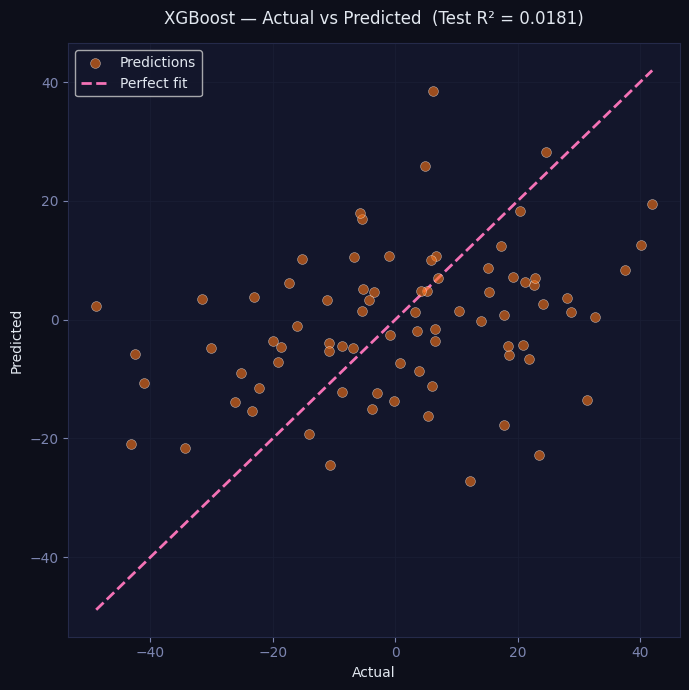

In [28]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_test, alpha=0.6, color=ORANGE, edgecolors='white',
           linewidths=0.4, s=50, label='Predictions', zorder=3)

mn = min(y_test.min(), y_pred_test.min())
mx = max(y_test.max(), y_pred_test.max())
ax.plot([mn, mx], [mn, mx], '--', color=PINK, lw=2, label='Perfect fit', zorder=2)

ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'XGBoost — Actual vs Predicted  (Test R² = {test_r2:.4f})', pad=14)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### 10.2 Training Loss Curve (per Boosting Round)

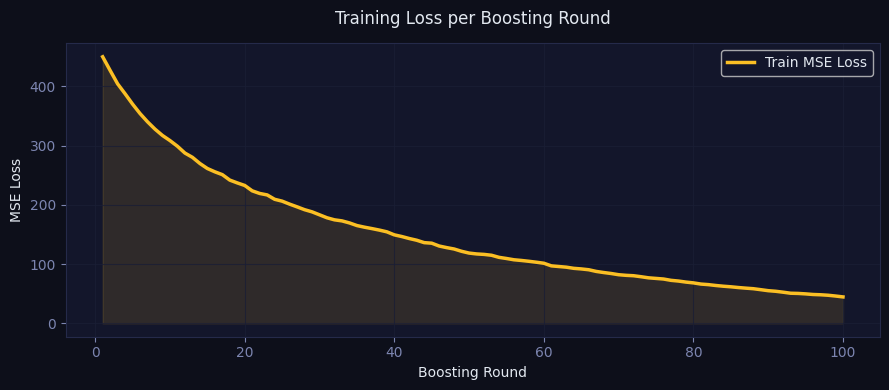

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
rounds = np.arange(1, len(model.train_loss_) + 1)
ax.plot(rounds, model.train_loss_, color=AMBER, lw=2.5, label='Train MSE Loss')
ax.fill_between(rounds, model.train_loss_, alpha=0.12, color=AMBER)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss per Boosting Round', pad=14)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### 10.3 Feature Importances

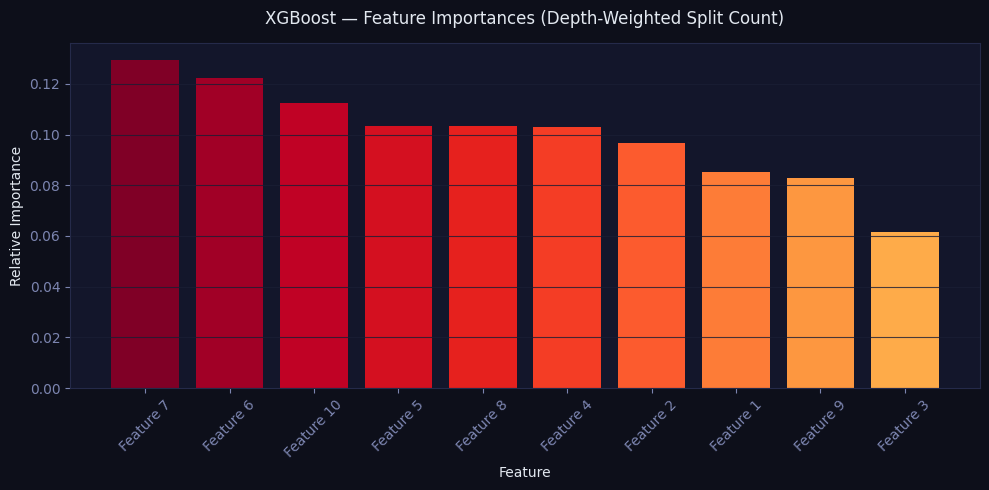


Feature importances (descending):
  Feature 7: 0.1295
  Feature 6: 0.1223
  Feature 10: 0.1123
  Feature 5: 0.1034
  Feature 8: 0.1034
  Feature 4: 0.1030
  Feature 2: 0.0966
  Feature 1: 0.0851
  Feature 9: 0.0827
  Feature 3: 0.0617


In [30]:
importances = feature_importances(model)
feat_names  = [f'Feature {i+1}' for i in range(len(importances))]
sorted_idx  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.YlOrRd(np.linspace(0.4, 1.0, len(importances))[::-1])
bars = ax.bar(
    [feat_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color=colors, edgecolor='none',
)
ax.set_xlabel('Feature')
ax.set_ylabel('Relative Importance')
ax.set_title('XGBoost — Feature Importances (Depth-Weighted Split Count)', pad=14)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

print('\nFeature importances (descending):')
for i in sorted_idx:
    print(f'  {feat_names[i]}: {importances[i]:.4f}')

### 10.4 Learning Rate Sweep

Running learning rate sweep...
  lr=0.001  →  R²=0.0111  MSE=407.97
  lr=0.010  →  R²=0.0946  MSE=373.50
  lr=0.050  →  R²=0.1502  MSE=350.57
  lr=0.100  →  R²=0.1360  MSE=356.42
  lr=0.200  →  R²=0.0556  MSE=389.59
  lr=0.300  →  R²=-0.0773  MSE=444.45
  lr=0.500  →  R²=-0.3726  MSE=566.26


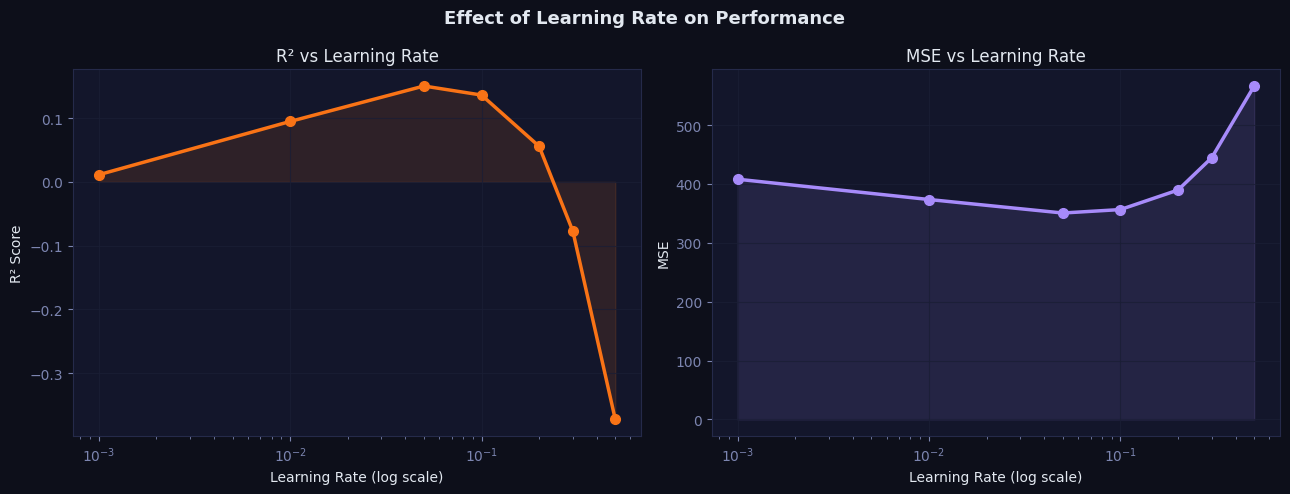

In [31]:
lr_values = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
lr_r2_scores = []
lr_mse_scores = []

print('Running learning rate sweep...')
for lr in lr_values:
    m = XGBoostRegressor(
        n_estimators=80, max_depth=3,
        learning_rate=lr, reg_lambda=1.0, random_state=42
    ).fit(X_train, y_train)
    lr_r2_scores.append(r2_score(y_test, m.predict(X_test)))
    lr_mse_scores.append(mean_squared_error(y_test, m.predict(X_test)))
    print(f'  lr={lr:.3f}  →  R²={lr_r2_scores[-1]:.4f}  MSE={lr_mse_scores[-1]:.2f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(lr_values, lr_r2_scores, 'o-', color=ORANGE, lw=2.5, ms=7)
ax1.fill_between(lr_values, lr_r2_scores, alpha=0.12, color=ORANGE)
ax1.set_xscale('log')
ax1.set_xlabel('Learning Rate (log scale)')
ax1.set_ylabel('R² Score')
ax1.set_title('R² vs Learning Rate')
ax1.grid(True)

ax2.plot(lr_values, lr_mse_scores, 'o-', color=VIOLET, lw=2.5, ms=7)
ax2.fill_between(lr_values, lr_mse_scores, alpha=0.12, color=VIOLET)
ax2.set_xscale('log')
ax2.set_xlabel('Learning Rate (log scale)')
ax2.set_ylabel('MSE')
ax2.set_title('MSE vs Learning Rate')
ax2.grid(True)

fig.suptitle('Effect of Learning Rate on Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.5 n_estimators Sweep (Early Stopping Insight)

In [ ]:
est_values = [5, 10, 20, 30, 50, 75, 100, 150, 200]
est_train_r2, est_test_r2 = [], []

print('Running n_estimators sweep...')
for n in est_values:
    m = XGBoostRegressor(
        n_estimators=n, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=42
    ).fit(X_train, y_train)
    est_train_r2.append(r2_score(y_train, m.predict(X_train)))
    est_test_r2.append(r2_score(y_test, m.predict(X_test)))
    print(f'  n={n:3d}  Train R²={est_train_r2[-1]:.4f}  Test R²={est_test_r2[-1]:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(est_values, est_train_r2, 'o-', color=GREEN,  lw=2.5, ms=7, label='Train R²')
ax.plot(est_values, est_test_r2,  's-', color=ORANGE, lw=2.5, ms=7, label='Test  R²')
ax.fill_between(est_values, est_train_r2, est_test_r2, alpha=0.1, color='white')
ax.set_xlabel('Number of Estimators (n_estimators)')
ax.set_ylabel('R² Score')
ax.set_title('Train vs Test R² as a function of n_estimators', pad=14)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

Running n_estimators sweep...
  n=  5  Train R²=0.2240  Test R²=0.0794
  n= 10  Train R²=0.3530  Test R²=0.1165
  n= 20  Train R²=0.5119  Test R²=0.1729


### 10.6 Regularisation Effect (Lambda Sweep)

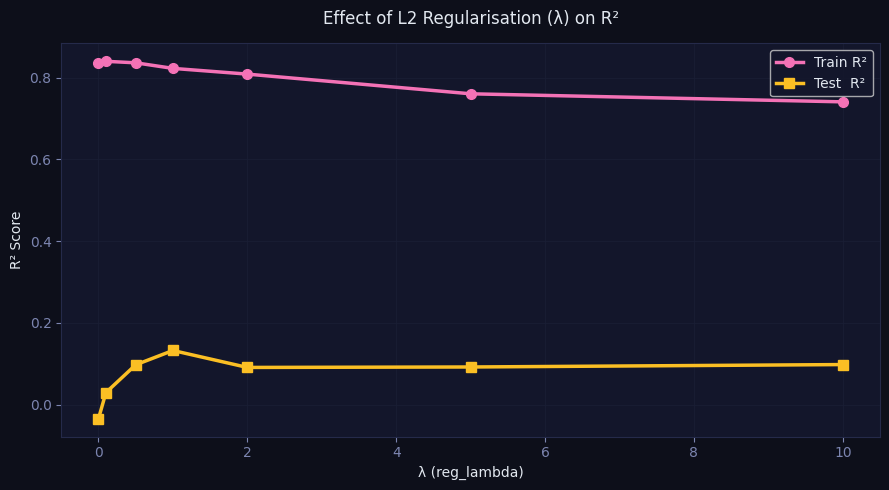

In [ ]:
lambda_values = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
lam_train_r2, lam_test_r2 = [], []

for lam in lambda_values:
    m = XGBoostRegressor(
        n_estimators=80, max_depth=4, learning_rate=0.1,
        reg_lambda=lam, random_state=42
    ).fit(X_train, y_train)
    lam_train_r2.append(r2_score(y_train, m.predict(X_train)))
    lam_test_r2.append(r2_score(y_test, m.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lambda_values, lam_train_r2, 'o-', color=PINK,   lw=2.5, ms=7, label='Train R²')
ax.plot(lambda_values, lam_test_r2,  's-', color=AMBER,  lw=2.5, ms=7, label='Test  R²')
ax.set_xlabel('λ (reg_lambda)')
ax.set_ylabel('R² Score')
ax.set_title('Effect of L2 Regularisation (λ) on R²', pad=14)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### 10.7 Residual Distribution

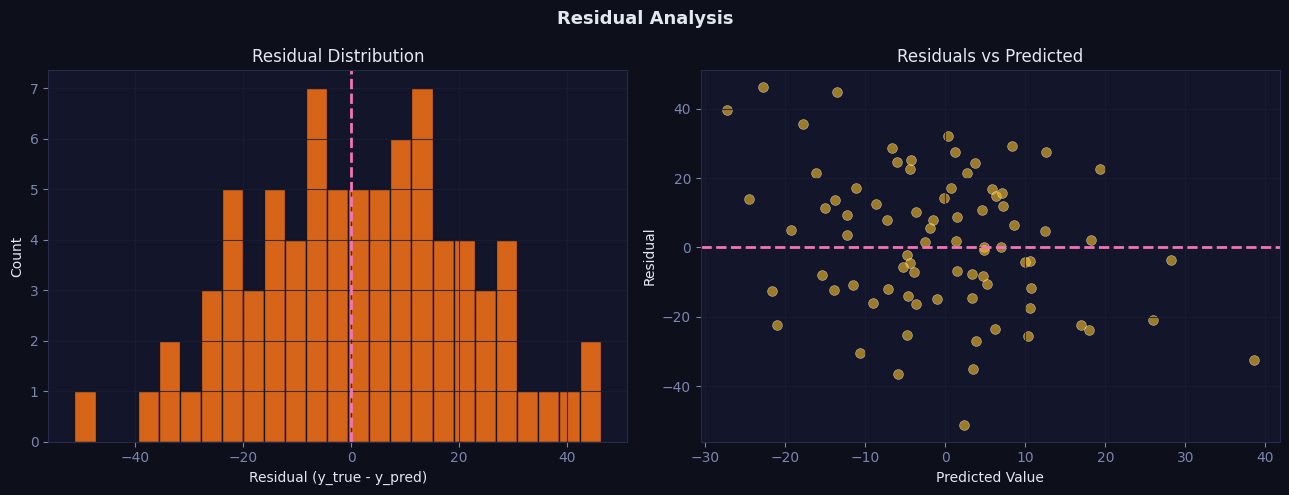

Mean Residual : 1.4702
Std  Residual : 20.0728


In [ ]:
residuals = y_test - y_pred_test

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
ax1.hist(residuals, bins=25, color=ORANGE, edgecolor='#0d0f1a', alpha=0.85)
ax1.axvline(0, color=PINK, lw=2, linestyle='--')
ax1.set_xlabel('Residual (y_true - y_pred)')
ax1.set_ylabel('Count')
ax1.set_title('Residual Distribution')
ax1.grid(True)

# Residuals vs Predicted
ax2.scatter(y_pred_test, residuals, alpha=0.6, color=AMBER, edgecolors='white',
            linewidths=0.4, s=50)
ax2.axhline(0, color=PINK, lw=2, linestyle='--')
ax2.set_xlabel('Predicted Value')
ax2.set_ylabel('Residual')
ax2.set_title('Residuals vs Predicted')
ax2.grid(True)

fig.suptitle('Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean Residual : {residuals.mean():.4f}')
print(f'Std  Residual : {residuals.std():.4f}')

## 11. Summary Dashboard

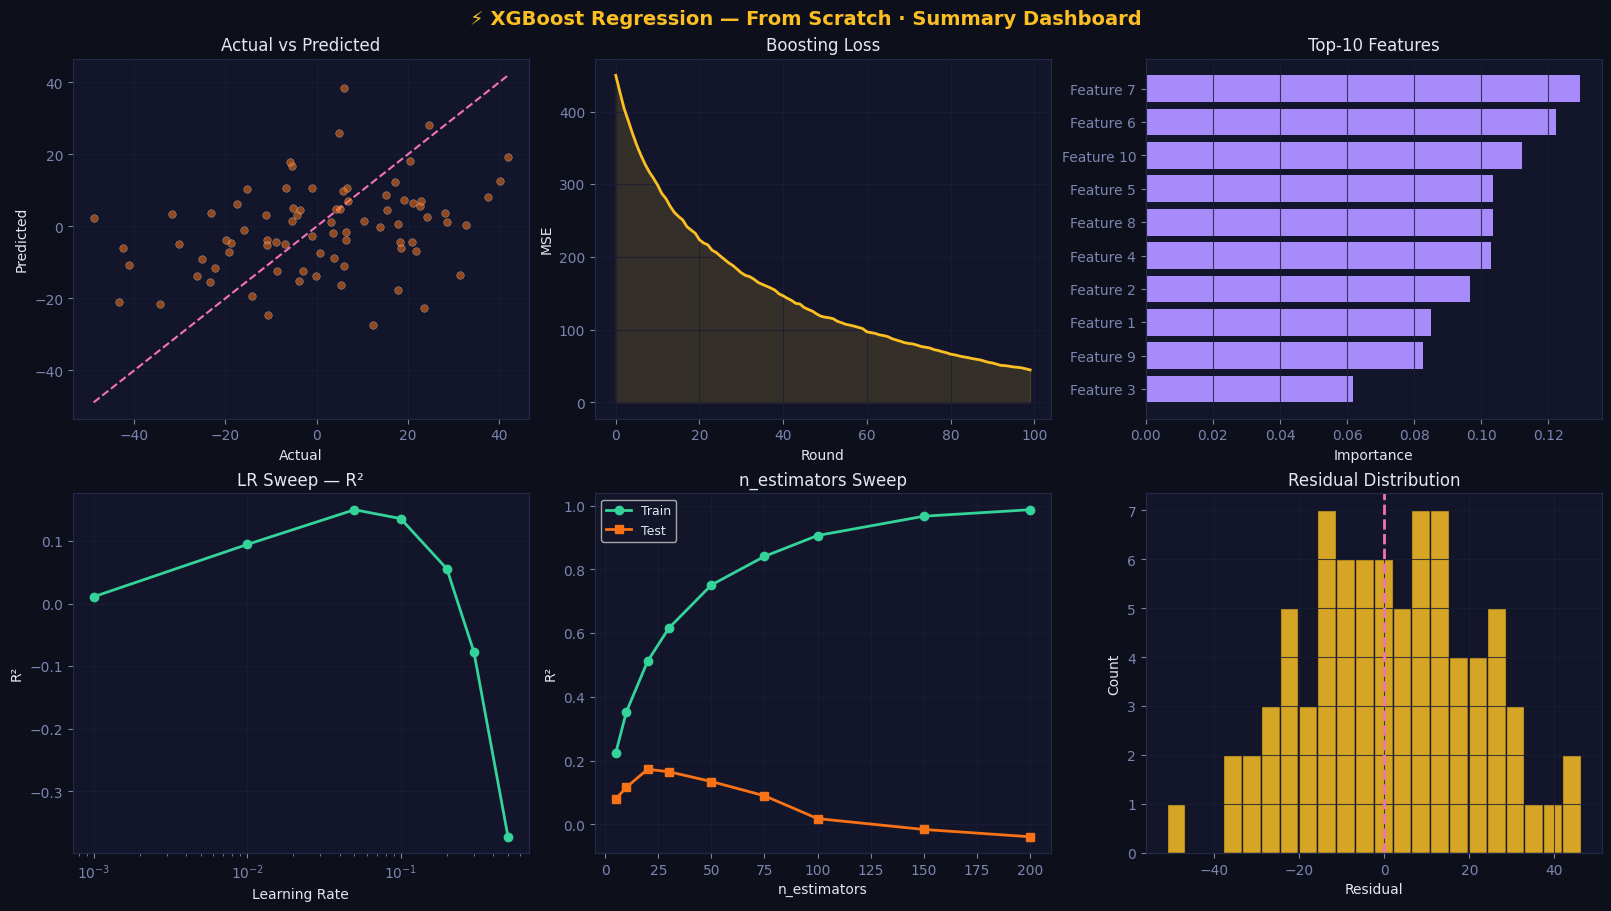

In [ ]:
fig = plt.figure(figsize=(16, 9), constrained_layout=True)
gs  = gridspec.GridSpec(2, 3, figure=fig)

# ── Actual vs Predicted ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred_test, alpha=0.55, color=ORANGE, edgecolors='white',
            linewidths=0.3, s=30, zorder=3)
mn_, mx_ = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
ax1.plot([mn_, mx_], [mn_, mx_], '--', color=PINK, lw=1.5)
ax1.set_title('Actual vs Predicted')
ax1.set_xlabel('Actual'); ax1.set_ylabel('Predicted')
ax1.grid(True)

# ── Training Loss ─────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(model.train_loss_, color=AMBER, lw=2)
ax2.fill_between(range(len(model.train_loss_)), model.train_loss_, alpha=0.15, color=AMBER)
ax2.set_title('Boosting Loss')
ax2.set_xlabel('Round'); ax2.set_ylabel('MSE')
ax2.grid(True)

# ── Feature Importance ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
top_n = 10
top_idx = sorted_idx[:top_n]
ax3.barh([feat_names[i] for i in top_idx[::-1]], importances[top_idx[::-1]],
         color=VIOLET, edgecolor='none')
ax3.set_title(f'Top-{top_n} Features')
ax3.set_xlabel('Importance')
ax3.grid(True, axis='x')

# ── LR Sweep ──────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(lr_values, lr_r2_scores, 'o-', color=GREEN, lw=2, ms=6)
ax4.set_xscale('log')
ax4.set_title('LR Sweep — R²')
ax4.set_xlabel('Learning Rate'); ax4.set_ylabel('R²')
ax4.grid(True)

# ── n_estimators Sweep ────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(est_values, est_train_r2, 'o-', color=GREEN,  lw=2, ms=6, label='Train')
ax5.plot(est_values, est_test_r2,  's-', color=ORANGE, lw=2, ms=6, label='Test')
ax5.set_title('n_estimators Sweep')
ax5.set_xlabel('n_estimators'); ax5.set_ylabel('R²')
ax5.legend(fontsize=9); ax5.grid(True)

# ── Residuals ─────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(residuals, bins=22, color=AMBER, edgecolor='#0d0f1a', alpha=0.85)
ax6.axvline(0, color=PINK, lw=2, linestyle='--')
ax6.set_title('Residual Distribution')
ax6.set_xlabel('Residual'); ax6.set_ylabel('Count')
ax6.grid(True)

fig.suptitle('⚡ XGBoost Regression — From Scratch · Summary Dashboard',
             fontsize=14, fontweight='bold', color=AMBER)
plt.show()

## 12. Quick Prediction

In [ ]:
# Predict a single sample
sample = X_test[0].reshape(1, -1)
pred   = model.predict(sample)
actual = y_test[0]

print(f'Sample features : {sample.flatten().round(3)}')
print(f'Predicted value : {pred[0]:.4f}')
print(f'Actual value    : {actual:.4f}')
print(f'Absolute error  : {abs(pred[0] - actual):.4f}')

Sample features : [ 0.327  0.3    0.622 -1.139  1.039 -0.076  0.67  -1.072 -1.554  0.818]
Predicted value : -5.8485
Actual value    : -42.5129
Absolute error  : 36.6644


---

## 📌 Key Takeaways

| Concept | Detail |
|---|---|
| **Loss** | MSE — gradient = residual, hessian = 1 |
| **Leaf weight** | `w* = -G / (H + λ)` with optional L1 soft-threshold |
| **Split gain** | `0.5 * [G_L²/(H_L+λ) + G_R²/(H_R+λ) - G²/(H+λ)] - γ` |
| **Initialisation** | `F_0 = mean(y)` |
| **Update** | `F_t = F_{t-1} + η * tree_t(x)` |
| **Row subsampling** | Reduces overfitting, adds stochasticity |
| **Column subsampling** | Similar to Random Forest column selection |
| **L2 (λ)** | Smooths leaf weights, reduces variance |
| **L1 (α)** | Sparsifies leaf weights via soft-thresholding |
| **γ (gamma)** | Minimum gain threshold — prunes unprofitable splits |